# 01 - Simulate PD-Centric Quarterly Panel

This notebook creates a clean synthetic quarterly panel for use in testing PTO, black-box, and DFL approaches.

- the latent credit-risk process is a true quarterly PD process, `PD_quarterly_true`;
- annual PD is derived as `PD_annual_true = 1 - (1 - PD_quarterly_true) ** 4` for Basel IRB;
- realised quarterly default and charge-off rates are sampled conditional on `PD_quarterly_true`;
- the Vasicek asset correlation and Basel IRB capital use `PD_annual_true`;
- oracle allocations use realised quarterly charge-offs and a linear shortfall penalty;
- a Bayes-oracle allocation maximises expected utility under the true Vasicek loss distribution given true PD, so downstream regret can be decomposed into estimation error and irreducible loss noise;
- timing convention for downstream models: predict quarter t+1 from features dated t (macro observables, c_t, c_lag1). By construction of the simulation, x_t and c_t are observable at decision time - there is no reporting lag in the synthetic world.

## Frequency Convention

The empirical FRED `charge_off_rate` series is observed quarterly but reported at an annualised rate. The allocation problem is quarterly, so the simulated realised loss `c` is a quarterly charge-off rate.

The main calibration target is therefore quarterly. The historical annualised charge-off series is converted to a quarterly charge-off proxy and then to a quarterly PD proxy:

```python
hist_c_quarterly = hist_c_annualised / 4
hist_pd_quarterly = hist_c_quarterly / LGD
hist_pd_annual = 1 - (1 - hist_pd_quarterly) ** 4
```

The simulated process starts with `PD_quarterly_true`. Annual PD is derived from it for Basel IRB:

```python
PD_annual_true = 1 - (1 - PD_quarterly_true) ** 4
```

## Part 1 - Imports, paths, and empirical target data

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from scipy.special import owens_t

pd.set_option("display.float_format", "{:.6f}".format)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks" and PROJECT_ROOT.parent.name == "simulation":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
import sys
sys.path.insert(0, str(PROJECT_ROOT))
from minou_colors import MINOU_COLORS

DATA_DIR = PROJECT_ROOT / "simulation" / "data"
PROCESSED_DATA_DIR = DATA_DIR
FIGURE_DIR = PROJECT_ROOT / "simulation" / "figures" / "01_simulate_panel"

CSV_PATH = DATA_DIR / "simulated_pd_panel.csv"
METADATA_PATH = DATA_DIR / "simulated_pd_panel_metadata.json"
HIST_CHARGE_OFF_PATH = PROCESSED_DATA_DIR / "fred_loan_return_aligned.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Historical charge-off file: {HIST_CHARGE_OFF_PATH}")
print(f"CSV output: {CSV_PATH}")
print(f"Figure directory: {FIGURE_DIR}")

Project root: /Users/hannahokeeffe/Documents/Imperial/DFL_New
Historical charge-off file: /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/data/fred_loan_return_aligned.csv
CSV output: /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/data/simulated_pd_panel.csv
Figure directory: /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel


## Simulation calibration

Change this cell to recalibrate the panel. The key quarterly PD calibration controls are `beta0`, `beta1`, `pd_min`, and `pd_max`; the key allocation controls are `ell` and `lambda_shortfall`.

In [2]:
# Baseline sample and random seed
T = 1000
SEED = 42

# Credit and allocation constants
LGD = 0.45
K1 = 1.0
ell = 10  # leverage; the empirical PTO notebook's LEVERAGE is set to match this
Y_BAR = 0.0168
lambda_shortfall = 10.0
M = 2.5
# Allocation decisions are optimised continuously on [0, 1] (closed-form for the
# single-draw oracle, a bounded scalar solver for the expected-utility Bayes oracle)
# rather than snapped to a discrete grid; see compute_oracle_allocation and
# compute_bayes_allocation below.
ALPHA_BOUNDS = (0.0, 1.0)
ALPHA_OPT_XATOL = 1e-10

# Numerical clipping for inverse-normal and log calculations
PD_CLIP_LOW = 1e-6
PD_CLIP_HIGH = 0.99

# Quarterly PD calibration bounds. These are one-quarter PDs, not annual PDs.
pd_min = 0.001
pd_max = 0.014
beta0 = -1.764472
beta1 =1.782915
beta2 = 0.038343

# Vasicek draw scaling. RHO_SCALE = 1.0 uses the Basel annual-horizon asset correlation
# unchanged for the quarterly draw. Assumption: this makes realised quarterly losses
# heavier-tailed than the smooth, diversified FRED aggregate (see Table C); set < 1 to
# shrink the systematic loading of the quarterly draw if closer realised tails are wanted.
RHO_SCALE = 0.05

# Basel corporate PD floor (0.03%), matching the empirical PTO notebook. A no-op at this
# calibration (annual PD >= ~0.4%) but kept so the IRB function is identical across notebooks.
APPLY_PD_FLOOR = True
PD_FLOOR = 3e-4

print("Calibration loaded.")

Calibration loaded.


## Part 2 - Historical quarterly calibration targets

In [3]:
hist = pd.read_csv(HIST_CHARGE_OFF_PATH)
hist_c_annualised_raw = hist["charge_off_rate"].dropna().astype(float)

# In this project the FRED annualised rate is stored in percent units when values
# exceed 1. Convert to decimal rates before applying frequency transformations.
charge_off_scale = 100.0 if hist_c_annualised_raw.max() > 1 else 1.0
hist_c_annualised = hist_c_annualised_raw / charge_off_scale

# Convert the annualised empirical charge-off rate to the quarterly decision frequency.
hist_c_quarterly = hist_c_annualised / 4
hist_pd_quarterly = (hist_c_quarterly / LGD).clip(PD_CLIP_LOW, PD_CLIP_HIGH)
hist_pd_annual = 1 - (1 - hist_pd_quarterly) ** 4

print(f"Historical charge-off scale divisor: {charge_off_scale:g}")
print("Historical quarterly charge-off target, decimal units:")
display(hist_c_quarterly.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("hist_c_quarterly"))
print("Historical quarterly PD proxy, decimal units:")
display(hist_pd_quarterly.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("hist_pd_quarterly"))
print("Historical annual PD proxy for IRB comparison, decimal units:")
display(hist_pd_annual.describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("hist_pd_annual"))

Historical charge-off scale divisor: 100
Historical quarterly charge-off target, decimal units:


,hist_c_quarterly
count,165.000000
mean,0.001889
std,0.001433
min,0.000300
50%,0.001375
75%,0.003000
90%,0.003820
95%,0.004710
99%,0.005819
max,0.006425


Historical quarterly PD proxy, decimal units:


,hist_pd_quarterly
count,165.000000
mean,0.004197
std,0.003185
min,0.000667
50%,0.003056
75%,0.006667
90%,0.008489
95%,0.010467
99%,0.012931
max,0.014278


Historical annual PD proxy for IRB comparison, decimal units:


,hist_pd_annual
count,165.000000
mean,0.016623
std,0.012519
min,0.002664
50%,0.012166
75%,0.026401
90%,0.033525
95%,0.041214
99%,0.050729
max,0.055900


## Part 3 - Basel helper functions

In [4]:
def clip_pd(pd, low=PD_CLIP_LOW, high=PD_CLIP_HIGH):
    """Clip PD values to avoid numerical issues in log and inverse-normal terms."""
    return np.clip(np.asarray(pd, dtype=float), low, high)


def sigmoid(x):
    """Logistic transform used to map latent stress into bounded PDs."""
    return 1 / (1 + np.exp(-x))


def basel_R(pd_annual):
    """Corporate Basel asset correlation using annual PD."""
    pd_annual = clip_pd(pd_annual)
    exp_term = (1 - np.exp(-50 * pd_annual)) / (1 - np.exp(-50))
    return 0.12 * exp_term + 0.24 * (1 - exp_term)


def maturity_adjustment(pd_annual, M=2.5):
    """Basel maturity adjustment for corporate exposures, using annual PD."""
    pd_annual = clip_pd(pd_annual)
    b = (0.11852 - 0.05478 * np.log(pd_annual)) ** 2
    return (1 + (M - 2.5) * b) / (1 - 1.5 * b)


def k_irb(pd_annual, lgd=0.45, M=2.5, apply_floor=None):
    """Basel IRB capital requirement per unit exposure using annual PD.

    Matches the empirical PTO notebook: corporate PD floor applied before the
    correlation/maturity terms, and the requirement is floored at zero.
    """
    if apply_floor is None:
        apply_floor = APPLY_PD_FLOOR
    pd_annual = clip_pd(pd_annual)
    if apply_floor:
        pd_annual = np.maximum(pd_annual, PD_FLOOR)
    R = basel_R(pd_annual)
    numerator = norm.ppf(pd_annual) + np.sqrt(R) * norm.ppf(0.999)
    denominator = np.sqrt(1 - R)
    unexpected_loss = norm.cdf(numerator / denominator) - pd_annual
    return np.maximum(lgd * unexpected_loss * maturity_adjustment(pd_annual, M=M), 0.0)

## Part 4 - Vasicek quarterly default-rate sampler

In [5]:
def sample_vasicek_default_rate(pd_quarterly_true, pd_annual_true, seed=None, rho_scale=None):
    """Draw quarterly default and charge-off rates from the Vasicek model.

    Assumptions:
    - the portfolio is infinitely granular, so the realised default rate equals the
      Vasicek conditional default probability given the systematic factor Z;
    - the default threshold uses the quarterly PD because losses realise over one quarter;
    - the asset correlation follows the Basel annual-PD convention, scaled by RHO_SCALE,
      so the quarterly draw inherits an annual-horizon systematic loading;
    - Z is iid across quarters and independent of the latent macro state:
      PD_quarterly_true already conditions on the macro state, and Z is the residual
      within-quarter systematic shock, so charge-off surprises are serially independent
      given the PD path;
    - LGD is constant, so charge-offs are LGD times the default rate.
    """
    if rho_scale is None:
        rho_scale = RHO_SCALE
    rng = np.random.default_rng(seed)
    pd_quarterly_true = clip_pd(pd_quarterly_true)
    pd_annual_true = clip_pd(pd_annual_true)
    rho = np.clip(rho_scale * basel_R(pd_annual_true), 1e-4, 0.999)
    Z = rng.normal(0, 1, size=pd_quarterly_true.shape)

    default_rate_q = norm.cdf(
        (norm.ppf(pd_quarterly_true) - np.sqrt(rho) * Z) / np.sqrt(1 - rho)
    )
    default_rate_q = np.clip(default_rate_q, 0, 1)
    charge_off_rate_q = np.clip(LGD * default_rate_q, 0, LGD)
    return default_rate_q, charge_off_rate_q

## Part 5 - Simulate latent macro state

In [6]:
def simulate_latent_state(T=1000, phi=0.95, sigma=0.35, seed=42):
    """Simulate persistent latent stress and a second persistent component."""
    rng = np.random.default_rng(seed)
    state = np.zeros(T)
    cycle = np.zeros(T)

    for t in range(1, T):
        state[t] = phi * state[t - 1] + rng.normal(0, sigma)
        cycle[t] = 0.75 * cycle[t - 1] + rng.normal(0, 0.45)

    state = (state - state.mean()) / state.std(ddof=0)
    cycle = (cycle - cycle.mean()) / cycle.std(ddof=0)
    return pd.DataFrame({"latent_state": state, "latent_cycle": cycle})


latent = simulate_latent_state(T=T, seed=SEED)
latent.head()

,latent_state,latent_cycle
0,0.423821,0.115482
1,0.520914,-0.610616
2,0.755177,0.227594
3,0.116947,-0.709592
4,0.173025,-0.724119


## Part 6 - Generate observed macro variables

In [7]:
def generate_macro_variables(latent_df, seed=43):
    """Create noisy observed macro-financial predictors from latent stress."""
    rng = np.random.default_rng(seed)
    out = latent_df.copy()
    s = out["latent_state"].to_numpy()
    q = out["latent_cycle"].to_numpy()
    T_local = len(out)

    out["t"] = np.arange(T_local)
    out["date"] = pd.period_range(start="1980Q1", periods=T_local, freq="Q").astype(str)
    out["x_growth"] = -0.80 * s + 0.15 * q + rng.normal(0, 0.45, T_local)
    out["x_unemployment"] = 0.90 * s + 0.10 * q + rng.normal(0, 0.40, T_local)
    out["x_credit_spread"] = 0.70 * s + 0.30 * s**2 + 0.15 * q + rng.normal(0, 0.45, T_local)
    out["x_yield_curve"] = -0.50 * s + 0.25 * q + rng.normal(0, 0.50, T_local)
    out["x_house_price_growth"] = -0.60 * s - 0.15 * q + rng.normal(0, 0.45, T_local)
    return out


macro_cols = [
    "x_growth",
    "x_unemployment",
    "x_credit_spread",
    "x_yield_curve",
    "x_house_price_growth",
]

df = generate_macro_variables(latent, seed=SEED + 1)
df[["t", "date", "latent_state", "latent_cycle"] + macro_cols].head()

,t,date,latent_state,latent_cycle,x_growth,x_unemployment,x_credit_spread,x_yield_curve,x_house_price_growth
0,0,1980Q1,0.423821,0.115482,-0.211831,0.634831,0.484775,-0.884113,-0.472364
1,1,1980Q2,0.520914,-0.610616,-0.203143,0.897137,-0.055082,-0.208364,0.273917
2,2,1980Q3,0.755177,0.227594,-0.833491,0.699530,0.607612,-0.173439,-0.690280
3,3,1980Q4,0.116947,-0.709592,-0.608899,-0.001785,0.141476,0.415671,-0.206404
4,4,1981Q1,0.173025,-0.724119,-1.143365,-0.339549,0.567634,-0.941497,0.366174


## Part 7 - Generate and calibrate true quarterly PD path

In [8]:
def quarterly_pd_from_latent(latent_df, beta0, beta1, beta2, pd_min, pd_max):
    """Map latent stress into a bounded quarterly PD process."""
    s = latent_df["latent_state"].to_numpy()
    q = latent_df["latent_cycle"].to_numpy()
    nonlinear_component = 0.5 * s**2 + 0.25 * q
    pd_index = beta0 + beta1 * s + beta2 * nonlinear_component
    pd_quarterly = pd_min + sigmoid(pd_index) * (pd_max - pd_min)
    return np.clip(pd_quarterly, PD_CLIP_LOW, PD_CLIP_HIGH)


def calibrate_pd_beta_grid(latent_df, hist_pd_quarterly, pd_min, pd_max, beta2):
    """Choose beta0 and beta1 to match quarterly PD proxy mean and p95."""
    target_mean = hist_pd_quarterly.mean()
    target_p95 = hist_pd_quarterly.quantile(0.95)
    beta0_grid = np.linspace(-4.5, 0.5, 201)
    beta1_grid = np.linspace(0.2, 2.8, 131)

    best = None
    for b0 in beta0_grid:
        for b1 in beta1_grid:
            pd_candidate = quarterly_pd_from_latent(latent_df, b0, b1, beta2, pd_min, pd_max)
            mean_err = (pd_candidate.mean() - target_mean) / target_mean
            p95_err = (np.quantile(pd_candidate, 0.95) - target_p95) / target_p95
            score = mean_err**2 + p95_err**2
            if best is None or score < best["score"]:
                best = {"beta0": b0, "beta1": b1, "score": score, "mean_err": mean_err, "p95_err": p95_err}
    return best


df["PD_quarterly_true"] = quarterly_pd_from_latent(df, beta0, beta1, beta2, pd_min, pd_max)
df["PD_annual_true"] = 1 - (1 - df["PD_quarterly_true"]) ** 4

# Compatibility alias: in this notebook PD_true means true quarterly PD.
# New code should prefer the explicit name PD_quarterly_true.
df["PD_true"] = df["PD_quarterly_true"]

df["expected_c_quarterly"] = LGD * df["PD_quarterly_true"]
df["expected_c_annualised"] = 4 * df["expected_c_quarterly"]

pd_summary = df[["PD_quarterly_true", "PD_annual_true", "expected_c_quarterly"]].agg(
    ["mean", "std", "min", "median", lambda x: x.quantile(0.95), "max"]
)
pd_summary.index = ["mean", "std", "min", "median", "p95", "max"]
pd_summary

,PD_quarterly_true,PD_annual_true,expected_c_quarterly
mean,0.004157,0.016467,0.001871
std,0.003092,0.012153,0.001391
min,0.001014,0.004048,0.000456
median,0.003029,0.012061,0.001363
p95,0.010734,0.042250,0.004830
max,0.013837,0.054211,0.006227


## Part 8 - Draw quarterly realised defaults and charge-offs

In [9]:
def add_realised_losses(panel, seed=44):
    """Add quarterly default rates, quarterly charge-offs, and annualised realised charge-offs."""
    out = panel.copy()
    default_rate_q, c_q = sample_vasicek_default_rate(
        out["PD_quarterly_true"].to_numpy(),
        out["PD_annual_true"].to_numpy(),
        seed=seed,
    )
    out["default_rate"] = default_rate_q
    out["c"] = c_q
    out["c_annualised_sim"] = 4 * out["c"]
    out["c_lag1"] = out["c"].shift(1)
    return out


df = add_realised_losses(df, seed=SEED + 2)
df[["t", "PD_quarterly_true", "PD_annual_true", "expected_c_quarterly", "default_rate", "c", "c_annualised_sim", "c_lag1"]].head()

,t,PD_quarterly_true,PD_annual_true,expected_c_quarterly,default_rate,c,c_annualised_sim,c_lag1
0,0,0.004485,0.017821,0.002018,0.002909,0.001309,0.005236,NaN
1,1,0.004930,0.019574,0.002218,0.004651,0.002093,0.008372,0.001309
2,2,0.006202,0.024577,0.002791,0.005557,0.002501,0.010002,0.002093
3,3,0.003253,0.012948,0.001464,0.002236,0.001006,0.004024,0.002501
4,4,0.003445,0.013711,0.001550,0.002611,0.001175,0.004700,0.001006


## Part 9 - Compute Basel capital requirement from annual PD

In [10]:
df["R_true"] = basel_R(df["PD_annual_true"].to_numpy())
df["K_IRB_true"] = k_irb(df["PD_annual_true"].to_numpy(), lgd=LGD, M=M)

df[["t", "PD_annual_true", "R_true", "K_IRB_true"]].head()

,t,PD_annual_true,R_true,K_IRB_true
0,0,0.017821,0.169227,0.088914
1,1,0.019574,0.165096,0.091328
2,2,0.024577,0.155116,0.097269
3,3,0.012948,0.182810,0.080652
4,4,0.013711,0.180459,0.082144


## Part 10 - Allocation objective and oracle allocation

In [11]:
def realised_utility(alpha, c, k_irb_true, K1=K1, ell=ell, y_bar=Y_BAR, lambda_shortfall=lambda_shortfall):
    """Realised utility with a linear shortfall penalty.

    Defaults are the module constants so the function cannot silently diverge from the
    calibration cell.

    Buffer semantics (intentional): committed capital alpha*K1 is excluded from the
    available buffer. Algebraically identical to requiring K_IRB plus a fixed management
    buffer add-on of 1/ell per unit exposure; this is what makes the capital constraint
    bind in the interior of alpha in [0, 1] (without it the constraint never binds on
    [0, 1] and the allocation decision is degenerate at alpha = 1).
    """
    exposure = ell * alpha * K1
    terminal_capital = K1 + exposure * (y_bar - c)
    committed_capital = alpha * K1
    available_buffer = terminal_capital - committed_capital
    required_capital = k_irb_true * exposure
    shortfall = np.maximum(required_capital - available_buffer, 0)
    utility = terminal_capital - lambda_shortfall * shortfall

    return {
        "utility": utility,
        "shortfall": shortfall,
        "terminal_capital": terminal_capital,
        "required_capital": required_capital,
        "available_buffer": available_buffer,
    }


def realised_alpha_star(c_t, k_t, K1=K1, ell=ell, y_bar=Y_BAR, lambda_shortfall=lambda_shortfall):
    """Continuous-optimum realised allocation for one (c, k) draw.

    Maximises realised_utility(alpha) on [0, 1] with a bounded scalar solver (Brent's
    method via scipy.optimize.minimize_scalar), checking the two domain boundaries
    explicitly in case the unconstrained optimum falls outside [0, 1].
    """
    def neg_utility(alpha):
        return -float(realised_utility(alpha, c_t, k_t, K1=K1, ell=ell, y_bar=y_bar,
                                        lambda_shortfall=lambda_shortfall)["utility"])

    opt = minimize_scalar(neg_utility, bounds=ALPHA_BOUNDS, method="bounded",
                           options={"xatol": ALPHA_OPT_XATOL})
    candidates = [(0.0, -neg_utility(0.0)), (1.0, -neg_utility(1.0)), (float(opt.x), -float(opt.fun))]
    alpha_star, _ = max(candidates, key=lambda item: item[1])
    best_result = realised_utility(alpha_star, c_t, k_t, K1=K1, ell=ell, y_bar=y_bar,
                                    lambda_shortfall=lambda_shortfall)
    return alpha_star, best_result


def compute_oracle_allocation(c_values, k_irb_values):
    """Exact continuous-optimum realised oracle allocation for each quarter."""
    records = []

    for c_t, k_t in zip(c_values, k_irb_values):
        alpha_star, best = realised_alpha_star(c_t, k_t)
        records.append({"alpha_oracle": alpha_star, **{f"{key}_oracle": value for key, value in best.items()}})

    return pd.DataFrame(records)


oracle = compute_oracle_allocation(df["c"].to_numpy(), df["K_IRB_true"].to_numpy())
df = pd.concat([df.reset_index(drop=True), oracle], axis=1)

full = realised_utility(1.0, df["c"].to_numpy(), df["K_IRB_true"].to_numpy(), K1=K1, ell=ell, y_bar=Y_BAR, lambda_shortfall=lambda_shortfall)
zero = realised_utility(0.0, df["c"].to_numpy(), df["K_IRB_true"].to_numpy(), K1=K1, ell=ell, y_bar=Y_BAR, lambda_shortfall=lambda_shortfall)

df["alpha_full"] = 1.0
df["utility_full"] = full["utility"]
df["shortfall_full"] = full["shortfall"]
df["alpha_zero"] = 0.0
df["utility_zero"] = zero["utility"]

df[["t", "c", "K_IRB_true", "alpha_oracle", "utility_oracle", "shortfall_oracle"]].head()

,t,c,K_IRB_true,alpha_oracle,utility_oracle,shortfall_oracle
0,0,0.001309,0.088914,0.576625,1.089325,0.000000
1,1,0.002093,0.091328,0.566183,1.083269,0.000000
2,2,0.002501,0.097269,0.546540,1.078152,0.000000
3,3,0.001006,0.080652,0.606582,1.095803,0.000000
4,4,0.001175,0.082144,0.600532,1.093833,0.000000


## Part 10b - Bayes-oracle allocation

The perfect-foresight oracle above knows the realised charge-off draw, which no model can
achieve even in principle. The Bayes oracle maximises *expected* utility given the true
quarterly PD and the true Vasicek loss distribution - the best allocation achievable by a
perfectly specified model. Downstream regret can then be decomposed:

- regret vs Bayes oracle = estimation error (the model's fault);
- Bayes vs foresight-oracle gap = irreducible Vasicek noise (nobody's fault).

The expectation over the systematic factor Z is evaluated in closed form via the analytical Vasicek expected-shortfall formula (bivariate normal CDF / Owen's T function) rather than Gauss-Hermite quadrature - the same formula the PTO notebook uses for its own expected-utility decision, evaluated here at the true PD and true K_IRB rather than the model's estimates.

In [12]:
def bivariate_normal_cdf(h, k, rho):
    """Standard bivariate normal CDF Phi_2(h, k; rho) via Owen's T function (Owen, 1956).

    Phi_2(h, k; rho) = 1/2*(Phi(h) + Phi(k)) - T(h, a) - T(k, b) - delta
    with a = (k/h - rho) / sqrt(1 - rho^2), b = (h/k - rho) / sqrt(1 - rho^2), and
    delta = 0 if h*k > 0 (or h*k == 0 and h + k >= 0), else 1/2. Ported from
    02_pto_simulated_panel so both notebooks share one analytic formula.
    """
    h = np.asarray(h, dtype=float)
    k = np.asarray(k, dtype=float)
    rho = np.clip(np.asarray(rho, dtype=float), -0.999999, 0.999999)
    denom = np.sqrt(np.maximum(1.0 - rho ** 2, 1e-300))
    h_safe = np.where(h == 0.0, 1e-12, h)
    k_safe = np.where(k == 0.0, 1e-12, k)
    a = (k / h_safe - rho) / denom
    b = (h / k_safe - rho) / denom
    val = 0.5 * (norm.cdf(h) + norm.cdf(k)) - owens_t(h_safe, a) - owens_t(k_safe, b)
    hk = h * k
    delta = np.where((hk > 0.0) | ((hk == 0.0) & (h + k >= 0.0)), 0.0, 0.5)
    return val - delta


def vasicek_expected_shortfall(x, pd_q, rho):
    """Closed-form Vasicek expected shortfall ES(x; pd_q, rho) = E[(L - x)^+] for the
    conditional default-rate distribution L ~ Vasicek(pd_q, rho):

        ES(x; pd_q, rho) = Phi_2(Phi^-1(pd_q), y_x; sqrt(rho)) - x * Phi(y_x)
        y_x = (Phi^-1(pd_q) - Phi^-1(x) * sqrt(1 - rho)) / sqrt(rho)

    Ported from 02_pto_simulated_panel. x may be an array; pd_q and rho are scalars for a
    single prediction. x <= 0 (shortfall always binds) and x >= 1 (never binds) are handled
    as the analytical limits rather than passed through Phi^-1.
    """
    x = np.asarray(x, dtype=float)
    pd_q = float(clip_pd(pd_q))
    rho = float(np.clip(rho, 1e-6, 1.0 - 1e-6))
    a = norm.ppf(pd_q)
    sqrt_rho = np.sqrt(rho)
    sqrt_1mrho = np.sqrt(1.0 - rho)

    x_clipped = np.clip(x, PD_CLIP_LOW, PD_CLIP_HIGH)
    y_x = (a - norm.ppf(x_clipped) * sqrt_1mrho) / sqrt_rho
    es = bivariate_normal_cdf(a, y_x, sqrt_rho) - x_clipped * norm.cdf(y_x)

    es = np.where(x <= 0.0, pd_q - x, es)   # shortfall always binds below x = 0
    es = np.where(x >= 1.0, 0.0, es)        # shortfall never binds above x = 1
    return np.maximum(es, 0.0)


def compute_bayes_allocation(pd_q_values, pd_a_values, k_irb_values):
    """Allocation maximising expected utility under the true Vasicek loss distribution.

    Uses the closed-form Vasicek expected-shortfall formula above rather than
    Gauss-Hermite quadrature to average over the systematic factor: this is the exact
    same expected-utility formula that 02_pto_simulated_panel's optimise_alpha_expected
    uses for the model's own decision, evaluated here at the true PD and true K_IRB
    instead of the model's estimates. The resulting expected utility is smooth in alpha
    (no closed-form maximiser), so the optimum is found with a bounded scalar solver
    (Brent, via minimize_scalar), checking both domain boundaries explicitly.
    """
    records = []
    for pd_q_t, pd_a_t, k_t in zip(pd_q_values, pd_a_values, k_irb_values):
        rho_t = float(np.clip(RHO_SCALE * basel_R(pd_a_t), 1e-4, 0.999))
        pd_q_t = float(clip_pd(pd_q_t))

        def expected_utility(alpha, pd_q_t=pd_q_t, k_t=k_t, rho_t=rho_t):
            alpha = float(alpha)
            expected_terminal_capital = K1 + ell * alpha * (Y_BAR - LGD * pd_q_t)
            if alpha <= 0.0:
                # alpha = 0 has zero exposure and zero shortfall by construction
                return expected_terminal_capital
            x = ((1.0 - alpha) + ell * alpha * (Y_BAR - k_t)) / (ell * alpha * LGD)
            es = vasicek_expected_shortfall(np.array([x]), pd_q_t, rho_t)[0]
            return expected_terminal_capital - lambda_shortfall * ell * alpha * LGD * es

        opt = minimize_scalar(lambda a: -expected_utility(a), bounds=ALPHA_BOUNDS,
                               method="bounded", options={"xatol": ALPHA_OPT_XATOL})
        candidates = [(0.0, expected_utility(0.0)), (1.0, expected_utility(1.0)),
                      (float(opt.x), -float(opt.fun))]
        alpha_star, expected_u_star = max(candidates, key=lambda item: item[1])
        records.append({"alpha_bayes": alpha_star, "expected_utility_bayes": expected_u_star})
    return pd.DataFrame(records)


bayes = compute_bayes_allocation(
    df["PD_quarterly_true"].to_numpy(), df["PD_annual_true"].to_numpy(),
    df["K_IRB_true"].to_numpy())
df = pd.concat([df.reset_index(drop=True), bayes.reset_index(drop=True)], axis=1)

# Realised utility of the Bayes allocation at the realised draw, and the per-quarter
# irreducible-noise regret available only in simulation.
bayes_realised = realised_utility(df["alpha_bayes"].to_numpy(), df["c"].to_numpy(), df["K_IRB_true"].to_numpy())
df["utility_bayes_realised"] = bayes_realised["utility"]
df["shortfall_bayes_realised"] = bayes_realised["shortfall"]
df["regret_bayes_vs_oracle"] = df["utility_oracle"] - df["utility_bayes_realised"]
assert (df["regret_bayes_vs_oracle"] >= -1e-10).all()

display(df[["alpha_oracle", "alpha_bayes"]].describe().loc[["mean", "std", "min", "max"]])
print(f"Mean irreducible regret (foresight oracle minus realised Bayes utility): "
      f"{df['regret_bayes_vs_oracle'].mean():.4f}")

,alpha_oracle,alpha_bayes
mean,0.615047,0.610166
std,0.076816,0.078422
min,0.468060,0.461638
max,0.746420,0.742963


Mean irreducible regret (foresight oracle minus realised Bayes utility): 0.0009


## Part 11 - Model input and diagnostic column lists

In [13]:
# Timing convention for downstream notebooks: models predict next-quarter outcomes from
# information dated t. Feature rows are dated t and the target is PD/losses at t+1 (the
# downstream PTO/BB/DFL notebooks do the shifting, mirroring the empirical pipeline).
# Assumption: by construction of the simulation, x_t and the realised charge-off c_t are
# observable at decision time - there is no reporting lag in the synthetic world.
feature_cols = [
    "x_growth",
    "x_unemployment",
    "x_credit_spread",
    "x_yield_curve",
    "x_house_price_growth",
    "c",        # current-quarter realised charge-off, observable at decision time
    "c_lag1",   # previous quarter, gives models short-horizon dynamics
]

# Diagnostic-only columns are known inside the simulation or realised after the
# allocation decision. Later PTO/BB/DFL models must not use these as inputs.
# Note "c" is deliberately NOT in this list: c_t is a legitimate feature for predicting
# t+1, while c_{t+1} is the evaluation outcome (alignment handled downstream).
diagnostic_cols = [
    "latent_state",
    "latent_cycle",
    "PD_quarterly_true",
    "PD_annual_true",
    "PD_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "default_rate",
    "c_annualised_sim",
    "R_true",
    "K_IRB_true",
    "alpha_oracle",
    "utility_oracle",
    "shortfall_oracle",
    "alpha_bayes",
    "expected_utility_bayes",
    "utility_bayes_realised",
]

# Drop the first row after creating c_lag1 because the lag is unavailable there.
df = df.dropna(subset=["c_lag1"]).reset_index(drop=True)
df["t"] = np.arange(len(df))

print(f"Observations after creating c_lag1: {len(df)}")
print("Feature columns:", feature_cols)
print("Diagnostic-only columns:", diagnostic_cols)

Observations after creating c_lag1: 999
Feature columns: ['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c', 'c_lag1']
Diagnostic-only columns: ['latent_state', 'latent_cycle', 'PD_quarterly_true', 'PD_annual_true', 'PD_true', 'expected_c_quarterly', 'expected_c_annualised', 'default_rate', 'c_annualised_sim', 'R_true', 'K_IRB_true', 'alpha_oracle', 'utility_oracle', 'shortfall_oracle', 'alpha_bayes', 'expected_utility_bayes', 'utility_bayes_realised']


## Part 12 - Sanity checks

In [14]:
assert df["PD_quarterly_true"].between(0, 1).all()
assert df["PD_annual_true"].between(0, 1).all()
assert (df["PD_annual_true"] >= df["PD_quarterly_true"]).all()
assert df["default_rate"].between(0, 1).all()
assert (df["c"] >= 0).all()
assert (df["c"] <= LGD).all()
assert df["R_true"].between(0, 1).all()
assert (df["K_IRB_true"] >= 0).all()
assert df["alpha_oracle"].between(0, 1).all()
assert (df["shortfall_oracle"] >= 0).all()
assert df["alpha_bayes"].between(0, 1).all()
assert (df["regret_bayes_vs_oracle"] >= -1e-10).all()

for forbidden in [
    "PD_quarterly_true",
    "PD_annual_true",
    "PD_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "c_annualised_sim",
    "K_IRB_true",
    "alpha_oracle",
    "latent_state",
]:
    assert forbidden not in feature_cols

summary_cols = [
    "latent_state",
    "PD_quarterly_true",
    "PD_annual_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "default_rate",
    "c",
    "c_annualised_sim",
    "K_IRB_true",
    "alpha_oracle",
    "utility_oracle",
    "shortfall_oracle",
]

summary_table = df[summary_cols].describe(percentiles=[0.05, 0.50, 0.75, 0.90, 0.95, 0.99]).T
summary_table

,count,mean,std,min,5%,50%,75%,90%,95%,99%,max
latent_state,999.000000,-0.000424,1.000912,-2.950986,-1.723144,0.039567,0.728979,1.217913,1.577208,2.210749,3.318040
PD_quarterly_true,999.000000,0.004157,0.003093,0.001014,0.001109,0.003026,0.006041,0.008921,0.010736,0.012792,0.013837
PD_annual_true,999.000000,0.016466,0.012159,0.004048,0.004431,0.012048,0.023944,0.035208,0.042256,0.050195,0.054211
expected_c_quarterly,999.000000,0.001870,0.001392,0.000456,0.000499,0.001362,0.002718,0.004014,0.004831,0.005756,0.006227
expected_c_annualised,999.000000,0.007482,0.005568,0.001824,0.001997,0.005446,0.010873,0.016057,0.019324,0.023026,0.024907
default_rate,999.000000,0.004107,0.003346,0.000332,0.000874,0.002856,0.005693,0.009285,0.011335,0.014078,0.024834
c,999.000000,0.001848,0.001506,0.000149,0.000393,0.001285,0.002562,0.004178,0.005101,0.006335,0.011175
c_annualised_sim,999.000000,0.007393,0.006023,0.000597,0.001573,0.005141,0.010247,0.016714,0.020402,0.025340,0.044701
K_IRB_true,999.000000,0.080137,0.019672,0.050463,0.052669,0.078767,0.096576,0.107518,0.113560,0.120039,0.123218
alpha_oracle,999.000000,0.615086,0.076845,0.468060,0.494954,0.612494,0.684000,0.720659,0.733095,0.742157,0.746420


## Lowest oracle allocation quarters

In [15]:
lowest_alpha_diagnostic = df.nsmallest(10, "alpha_oracle")[[
    "alpha_oracle",
    "PD_quarterly_true",
    "PD_annual_true",
    "c",
    "c_annualised_sim",
    "expected_c_quarterly",
    "K_IRB_true",
]]

lowest_alpha_diagnostic

,alpha_oracle,PD_quarterly_true,PD_annual_true,c,c_annualised_sim,expected_c_quarterly,K_IRB_true
732,0.468060,0.012544,0.049238,0.011175,0.044701,0.005645,0.119273
162,0.468448,0.013837,0.054211,0.007053,0.028211,0.006227,0.123218
163,0.472671,0.013461,0.052768,0.006281,0.025123,0.006058,0.122083
165,0.473058,0.013364,0.052394,0.006403,0.025611,0.006014,0.121788
161,0.473326,0.013616,0.053361,0.005520,0.022080,0.006127,0.122551
160,0.475092,0.013375,0.052435,0.005465,0.021861,0.006019,0.121820
159,0.475777,0.013186,0.051709,0.005737,0.022948,0.005934,0.121245
166,0.477476,0.012858,0.050447,0.005994,0.023975,0.005786,0.120241
158,0.477882,0.012806,0.050249,0.005974,0.023896,0.005763,0.120083
156,0.477923,0.012585,0.049396,0.006639,0.026557,0.005663,0.119400


## Part 13 - Calibration diagnostics against empirical charge-offs

In [16]:
def moment_table(series, moments):
    """Return selected distribution moments for a one-dimensional series."""
    s = pd.Series(series).dropna().astype(float)
    values = {}
    for moment in moments:
        if moment == "mean":
            values[moment] = s.mean()
        elif moment == "std":
            values[moment] = s.std()
        elif moment == "median":
            values[moment] = s.median()
        elif moment.startswith("p"):
            values[moment] = s.quantile(float(moment[1:]) / 100)
        elif moment == "max":
            values[moment] = s.max()
        else:
            raise ValueError(f"Unknown moment: {moment}")
    return pd.Series(values)


def compare_moments(historical, simulated, moments, historical_label, simulated_label):
    """Compare historical and simulated moments with absolute and relative errors."""
    hist_moments = moment_table(historical, moments)
    sim_moments = moment_table(simulated, moments)
    comparison = pd.DataFrame({historical_label: hist_moments, simulated_label: sim_moments})
    comparison["absolute_error"] = comparison[simulated_label] - comparison[historical_label]
    comparison["relative_error"] = np.where(
        comparison[historical_label].abs() > 1e-12,
        comparison["absolute_error"] / comparison[historical_label],
        np.nan,
    )
    return comparison


moments = ["mean", "std", "median", "p75", "p90", "p95", "p99", "max"]

# Table A: main calibration target at the quarterly allocation frequency.
quarterly_expected_chargeoff_table = compare_moments(
    hist_c_quarterly,
    df["expected_c_quarterly"],
    moments,
    "hist_c_quarterly",
    "sim_expected_c_quarterly",
)

# Table B: annual PD comparison for the Basel IRB input.
annual_pd_table = compare_moments(
    hist_pd_annual,
    df["PD_annual_true"],
    moments,
    "hist_pd_annual_proxy",
    "sim_PD_annual_true",
)

# Table C: realised annualised charge-off diagnostic after Vasicek shocks.
realised_annualised_chargeoff_table = compare_moments(
    hist_c_annualised,
    df["c_annualised_sim"],
    moments,
    "hist_c_annualised",
    "sim_realised_c_annualised",
)

print("Table A - Quarterly expected charge-off calibration:")
display(quarterly_expected_chargeoff_table)
print("Table B - Annual PD comparison for Basel IRB:")
display(annual_pd_table)
print("Table C - Realised annualised charge-off diagnostic:")
display(realised_annualised_chargeoff_table)

main_mean_rel_error = abs(quarterly_expected_chargeoff_table.loc["mean", "relative_error"])
main_p95_rel_error = abs(quarterly_expected_chargeoff_table.loc["p95", "relative_error"])
annual_pd_mean_rel_error = abs(annual_pd_table.loc["mean", "relative_error"])
annual_pd_p95_rel_error = abs(annual_pd_table.loc["p95", "relative_error"])
realised_p95_rel_error = abs(realised_annualised_chargeoff_table.loc["p95", "relative_error"])

main_ok = (main_mean_rel_error <= 0.10) and (main_p95_rel_error <= 0.15)
annual_pd_ok = (annual_pd_mean_rel_error <= 0.10) and (annual_pd_p95_rel_error <= 0.15)

print(
    "Quarterly expected charge-off calibration acceptable? "
    f"{main_ok} (mean rel. error={main_mean_rel_error:.1%}, p95 rel. error={main_p95_rel_error:.1%})."
)
print(
    "Annual PD comparison acceptable? "
    f"{annual_pd_ok} (mean rel. error={annual_pd_mean_rel_error:.1%}, p95 rel. error={annual_pd_p95_rel_error:.1%})."
)
print(
    "Realised annualised charge-off p95 relative error after Vasicek shocks: "
    f"{realised_p95_rel_error:.1%}. This is diagnostic, not the direct calibration target."
)

Table A - Quarterly expected charge-off calibration:


,hist_c_quarterly,sim_expected_c_quarterly,absolute_error,relative_error
mean,0.001889,0.001870,-0.000018,-0.009639
std,0.001433,0.001392,-0.000041,-0.028929
median,0.001375,0.001362,-0.000013,-0.009796
p75,0.003000,0.002718,-0.000282,-0.093924
p90,0.003820,0.004014,0.000194,0.050866
p95,0.004710,0.004831,0.000121,0.025692
p99,0.005819,0.005756,-0.000063,-0.010756
max,0.006425,0.006227,-0.000198,-0.030854


Table B - Annual PD comparison for Basel IRB:


,hist_pd_annual_proxy,sim_PD_annual_true,absolute_error,relative_error
mean,0.016623,0.016466,-0.000157,-0.009426
std,0.012519,0.012159,-0.000360,-0.028781
median,0.012166,0.012048,-0.000119,-0.009752
p75,0.026401,0.023944,-0.002457,-0.093072
p90,0.033525,0.035208,0.001683,0.050193
p95,0.041214,0.042256,0.001042,0.025278
p99,0.050729,0.050195,-0.000534,-0.010529
max,0.055900,0.054211,-0.001689,-0.030212


Table C - Realised annualised charge-off diagnostic:


,hist_c_annualised,sim_realised_c_annualised,absolute_error,relative_error
mean,0.007555,0.007393,-0.000162,-0.021401
std,0.005734,0.006023,0.000289,0.050385
median,0.005500,0.005141,-0.000359,-0.065202
p75,0.012000,0.010247,-0.001753,-0.146100
p90,0.015280,0.016714,0.001434,0.093824
p95,0.018840,0.020402,0.001562,0.082917
p99,0.023276,0.025340,0.002064,0.088691
max,0.025700,0.044701,0.019001,0.739319


Quarterly expected charge-off calibration acceptable? True (mean rel. error=1.0%, p95 rel. error=2.6%).
Annual PD comparison acceptable? True (mean rel. error=0.9%, p95 rel. error=2.5%).
Realised annualised charge-off p95 relative error after Vasicek shocks: 8.3%. This is diagnostic, not the direct calibration target.


## Part 14 - Diagnostic visualisations

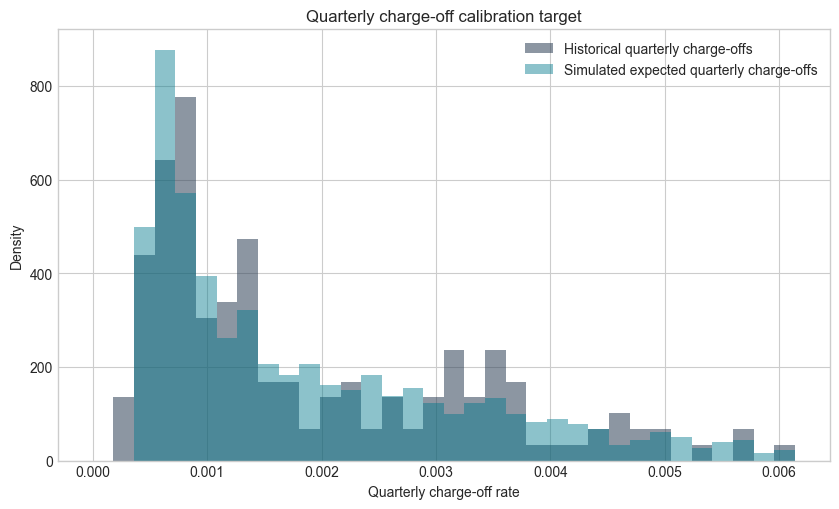

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/hist_vs_sim_expected_quarterly_chargeoffs.png


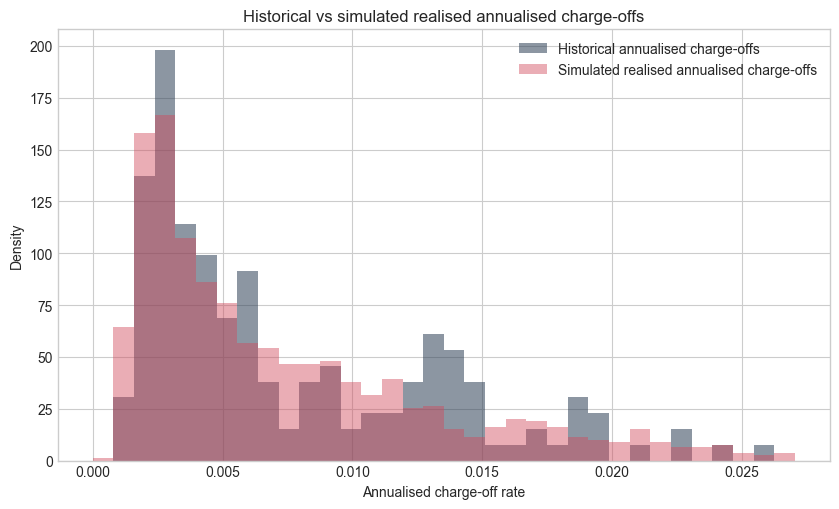

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/hist_vs_sim_annualised_chargeoffs.png


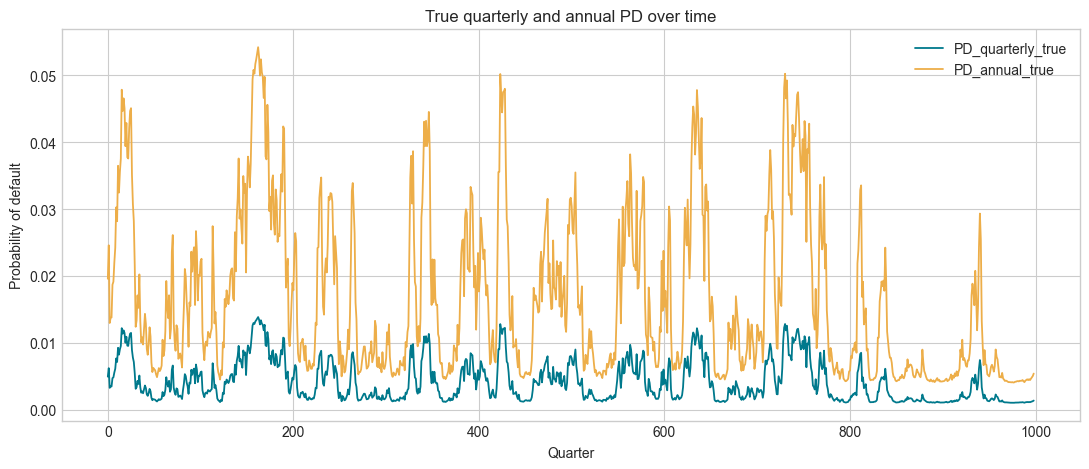

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/pd_quarterly_and_annual_over_time.png


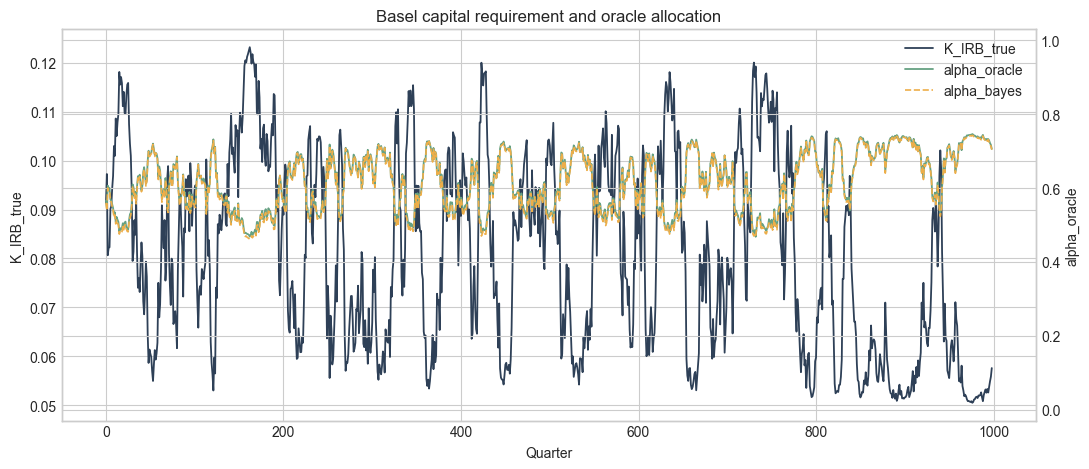

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/kirb_and_alpha_over_time.png


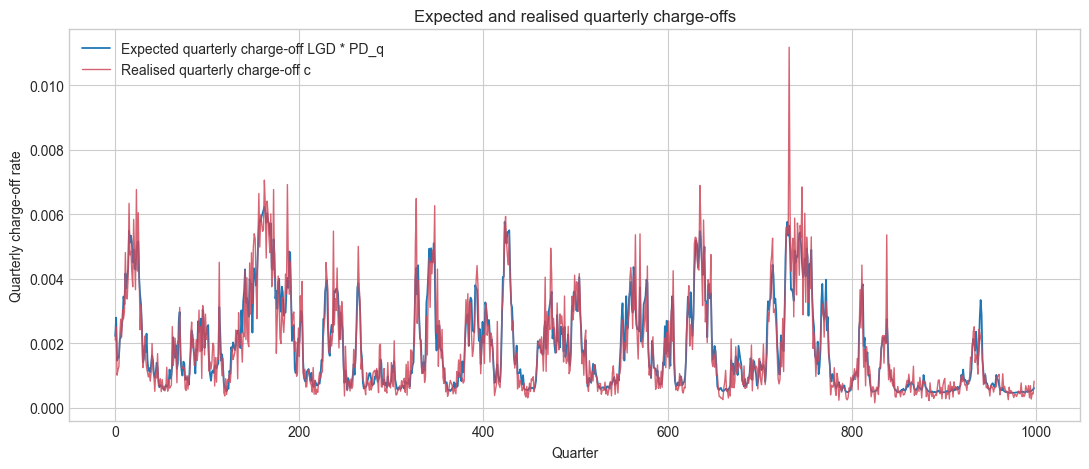

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/expected_vs_realised_quarterly_chargeoffs.png


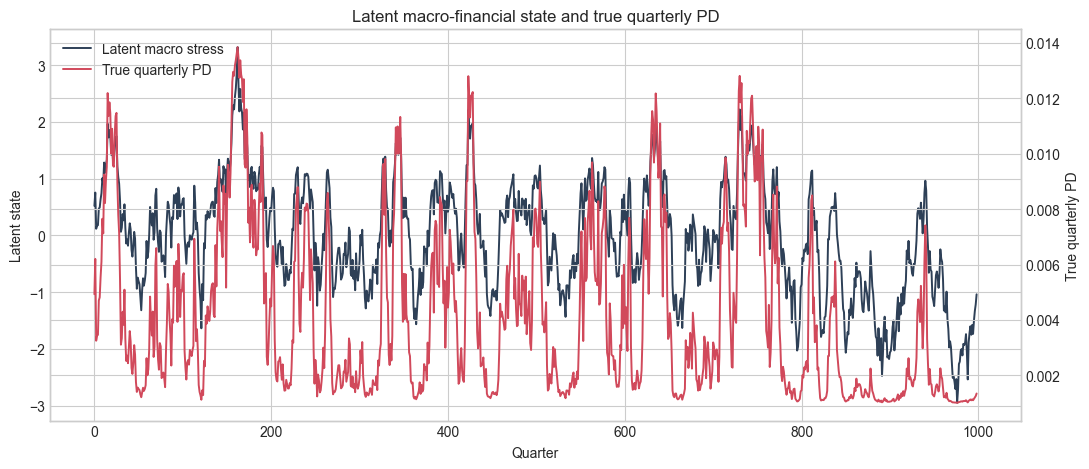

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/latent_state_and_pd.png


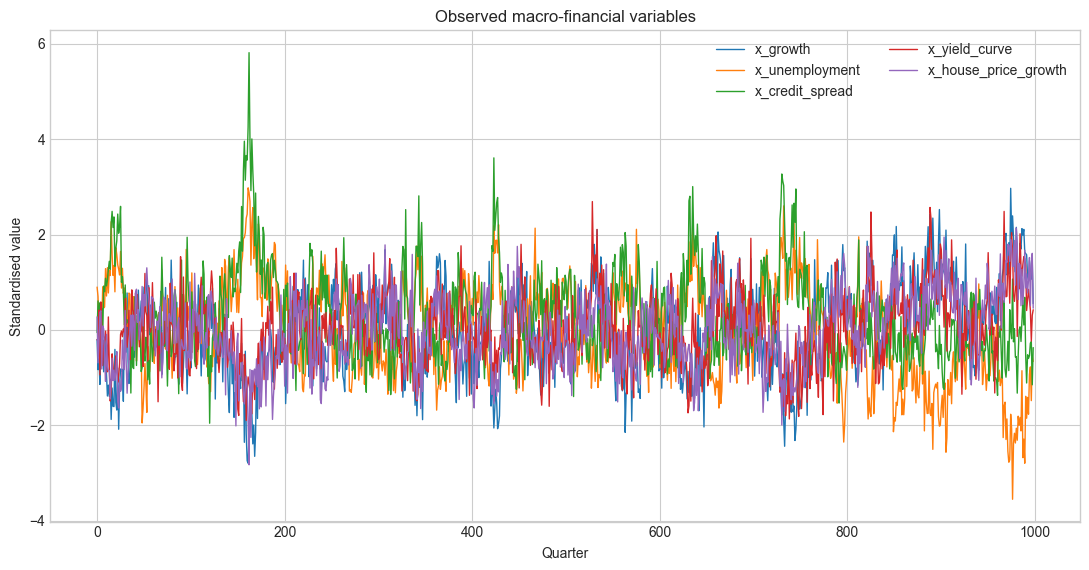

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/macro_variables.png


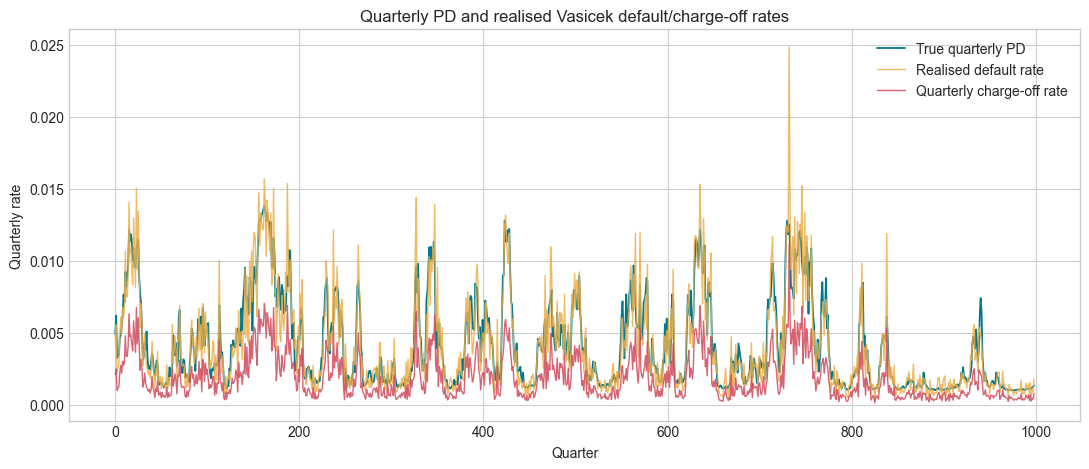

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/pd_and_chargeoffs.png


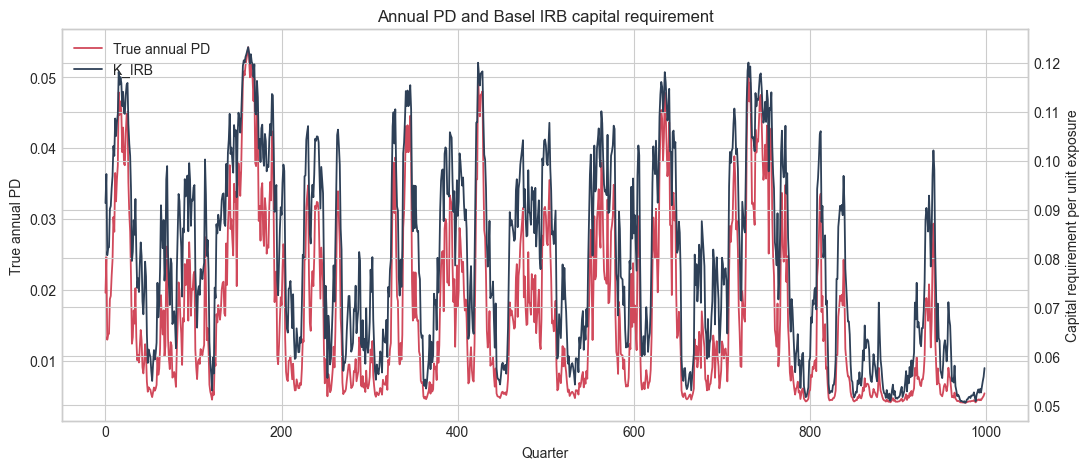

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/irb_and_pd.png


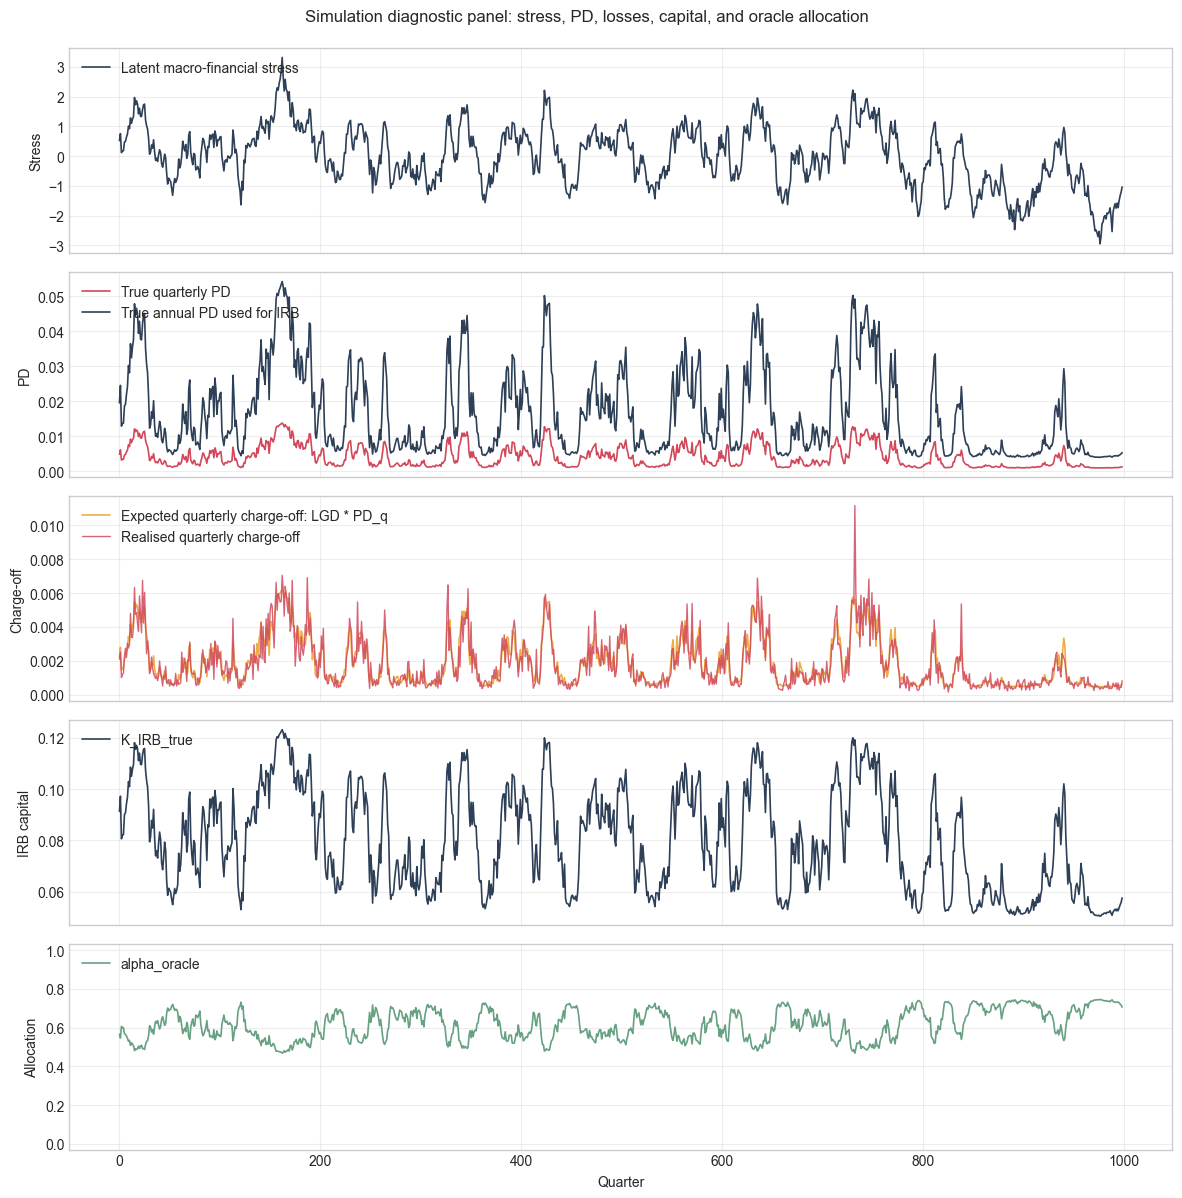

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/simulation_diagnostic_panel.png


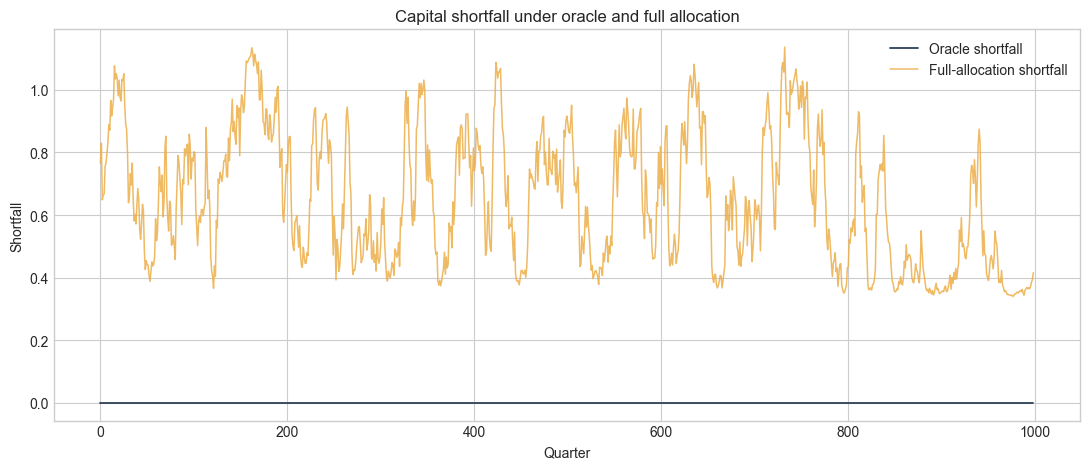

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/oracle_shortfall.png


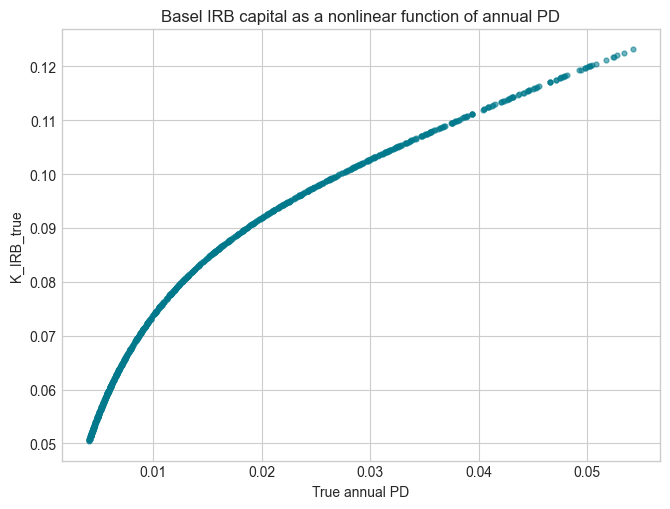

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/scatter_pd_kirb.png


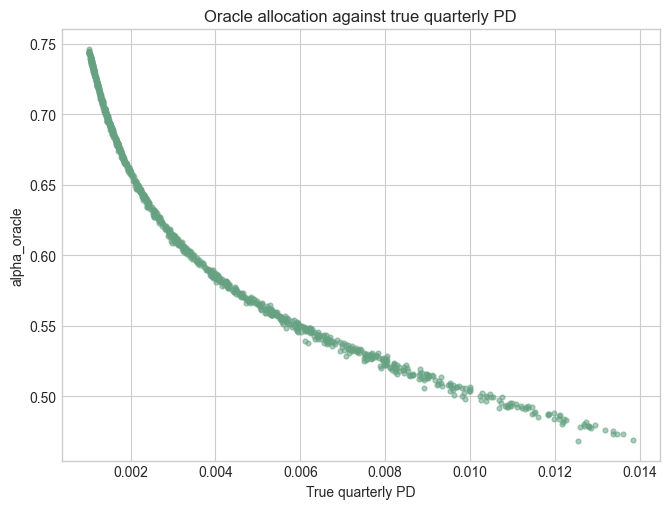

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/scatter_pd_alpha.png


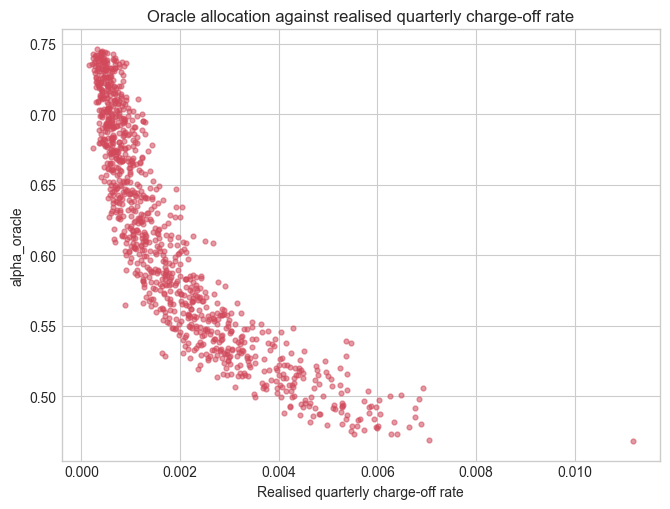

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/scatter_chargeoff_alpha.png


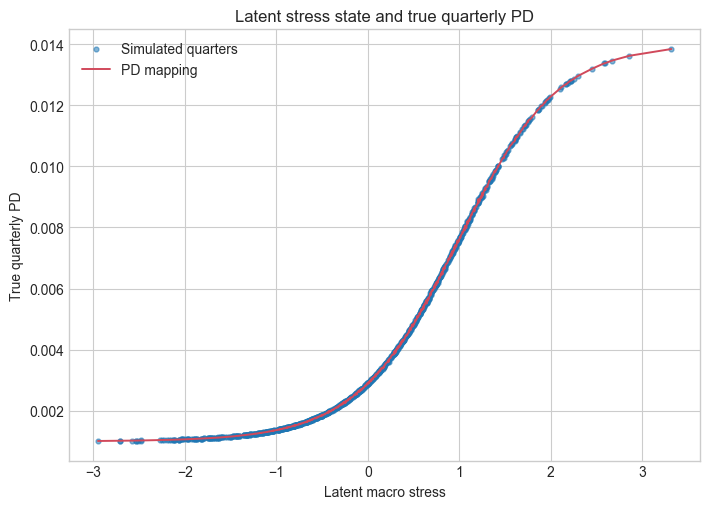

Saved /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/figures/01_simulate_panel/latent_stress_vs_pd_quarterly.png


In [17]:
plot_style = "seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "seaborn-whitegrid"
plt.style.use(plot_style)


def save_current_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {path}")


x = df["t"]

# 1. Historical quarterly target vs simulated expected quarterly charge-off distribution.
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bins = np.linspace(0, max(hist_c_quarterly.quantile(0.995), df["expected_c_quarterly"].quantile(0.995)), 35)
ax.hist(hist_c_quarterly, bins=bins, density=True, alpha=0.55, color=MINOU_COLORS["navy"], label="Historical quarterly charge-offs")
ax.hist(df["expected_c_quarterly"], bins=bins, density=True, alpha=0.45, color=MINOU_COLORS["teal"], label="Simulated expected quarterly charge-offs")
ax.set_title("Quarterly charge-off calibration target")
ax.set_xlabel("Quarterly charge-off rate")
ax.set_ylabel("Density")
ax.legend()
save_current_figure("hist_vs_sim_expected_quarterly_chargeoffs.png")

# 2. Historical annualised charge-offs vs simulated realised annualised charge-offs.
fig, ax = plt.subplots(figsize=(8.5, 5.2))
bins = np.linspace(0, max(hist_c_annualised.quantile(0.995), df["c_annualised_sim"].quantile(0.995)), 35)
ax.hist(hist_c_annualised, bins=bins, density=True, alpha=0.55, color=MINOU_COLORS["navy"], label="Historical annualised charge-offs")
ax.hist(df["c_annualised_sim"], bins=bins, density=True, alpha=0.45, color=MINOU_COLORS["coral"], label="Simulated realised annualised charge-offs")
ax.set_title("Historical vs simulated realised annualised charge-offs")
ax.set_xlabel("Annualised charge-off rate")
ax.set_ylabel("Density")
ax.legend()
save_current_figure("hist_vs_sim_annualised_chargeoffs.png")

# 3. Quarterly and annual true PD over time.
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["PD_quarterly_true"], color=MINOU_COLORS["teal"], label="PD_quarterly_true", linewidth=1.3)
ax.plot(x, df["PD_annual_true"], color=MINOU_COLORS["gold"], label="PD_annual_true", linewidth=1.3)
ax.set_title("True quarterly and annual PD over time")
ax.set_xlabel("Quarter")
ax.set_ylabel("Probability of default")
ax.legend()
save_current_figure("pd_quarterly_and_annual_over_time.png")

# 4. Basel capital and oracle allocation over time.
fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(x, df["K_IRB_true"], color=MINOU_COLORS["navy"], linewidth=1.3, label="K_IRB_true")
ax1.set_title("Basel capital requirement and oracle allocation")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("K_IRB_true")
ax2 = ax1.twinx()
ax2.plot(x, df["alpha_oracle"], color=MINOU_COLORS["sage"], linewidth=1.3, label="alpha_oracle")
ax2.plot(x, df["alpha_bayes"], color=MINOU_COLORS["gold"], linewidth=1.2, linestyle="--", label="alpha_bayes")
ax2.set_ylabel("alpha_oracle")
ax2.set_ylim(-0.03, 1.03)
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper right")
save_current_figure("kirb_and_alpha_over_time.png")

# 5. Realised quarterly charge-offs versus expected quarterly charge-offs.
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["expected_c_quarterly"], label="Expected quarterly charge-off LGD * PD_q", linewidth=1.3)
ax.plot(x, df["c"], color=MINOU_COLORS["coral"], label="Realised quarterly charge-off c", linewidth=1.0, alpha=0.85)
ax.set_title("Expected and realised quarterly charge-offs")
ax.set_xlabel("Quarter")
ax.set_ylabel("Quarterly charge-off rate")
ax.legend()
save_current_figure("expected_vs_realised_quarterly_chargeoffs.png")

# Supporting thesis diagnostics retained from the original notebook.
fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(x, df["latent_state"], color=MINOU_COLORS["navy"], linewidth=1.4, label="Latent macro stress")
ax1.set_title("Latent macro-financial state and true quarterly PD")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("Latent state")
ax2 = ax1.twinx()
ax2.plot(x, df["PD_quarterly_true"], color=MINOU_COLORS["coral"], linewidth=1.4, label="True quarterly PD")
ax2.set_ylabel("True quarterly PD")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
save_current_figure("latent_state_and_pd.png")

fig, ax = plt.subplots(figsize=(11, 5.8))
for col in macro_cols:
    ax.plot(x, df[col], linewidth=1.0, label=col)
ax.set_title("Observed macro-financial variables")
ax.set_xlabel("Quarter")
ax.set_ylabel("Standardised value")
ax.legend(ncol=2)
save_current_figure("macro_variables.png")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["PD_quarterly_true"], color=MINOU_COLORS["teal"], label="True quarterly PD", linewidth=1.3)
ax.plot(x, df["default_rate"], color=MINOU_COLORS["gold"], label="Realised default rate", linewidth=1.0, alpha=0.85)
ax.plot(x, df["c"], color=MINOU_COLORS["coral"], label="Quarterly charge-off rate", linewidth=1.0, alpha=0.85)
ax.set_title("Quarterly PD and realised Vasicek default/charge-off rates")
ax.set_xlabel("Quarter")
ax.set_ylabel("Quarterly rate")
ax.legend()
save_current_figure("pd_and_chargeoffs.png")

fig, ax1 = plt.subplots(figsize=(11, 4.8))
ax1.plot(x, df["PD_annual_true"], color=MINOU_COLORS["coral"], linewidth=1.3, label="True annual PD")
ax1.set_title("Annual PD and Basel IRB capital requirement")
ax1.set_xlabel("Quarter")
ax1.set_ylabel("True annual PD")
ax2 = ax1.twinx()
ax2.plot(x, df["K_IRB_true"], color=MINOU_COLORS["navy"], linewidth=1.3, label="K_IRB")
ax2.set_ylabel("Capital requirement per unit exposure")
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [line.get_label() for line in lines], loc="upper left")
save_current_figure("irb_and_pd.png")

fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)
fig.suptitle("Simulation diagnostic panel: stress, PD, losses, capital, and oracle allocation", y=0.995)

axes[0].plot(x, df["latent_state"], color=MINOU_COLORS["navy"], linewidth=1.2, label="Latent macro-financial stress")
axes[0].set_ylabel("Stress")
axes[0].legend(loc="upper left")

axes[1].plot(x, df["PD_quarterly_true"], color=MINOU_COLORS["coral"], linewidth=1.2, label="True quarterly PD")
axes[1].plot(x, df["PD_annual_true"], color=MINOU_COLORS["navy"], linewidth=1.2, label="True annual PD used for IRB")
axes[1].set_ylabel("PD")
axes[1].legend(loc="upper left")

axes[2].plot(x, df["expected_c_quarterly"], color=MINOU_COLORS["gold"], linewidth=1.2, label="Expected quarterly charge-off: LGD * PD_q")
axes[2].plot(x, df["c"], color=MINOU_COLORS["coral"], linewidth=1.0, alpha=0.85, label="Realised quarterly charge-off")
axes[2].set_ylabel("Charge-off")
axes[2].legend(loc="upper left")

axes[3].plot(x, df["K_IRB_true"], color=MINOU_COLORS["navy"], linewidth=1.2, label="K_IRB_true")
axes[3].set_ylabel("IRB capital")
axes[3].legend(loc="upper left")

axes[4].plot(x, df["alpha_oracle"], color=MINOU_COLORS["sage"], linewidth=1.2, label="alpha_oracle")
axes[4].set_ylabel("Allocation")
axes[4].set_xlabel("Quarter")
axes[4].set_ylim(-0.03, 1.03)
axes[4].legend(loc="upper left")

for ax in axes:
    ax.grid(True, alpha=0.35)

save_current_figure("simulation_diagnostic_panel.png")

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, df["shortfall_oracle"], color=MINOU_COLORS["navy"], label="Oracle shortfall", linewidth=1.3)
ax.plot(x, df["shortfall_full"], color=MINOU_COLORS["gold"], label="Full-allocation shortfall", linewidth=1.1, alpha=0.85)
ax.set_title("Capital shortfall under oracle and full allocation")
ax.set_xlabel("Quarter")
ax.set_ylabel("Shortfall")
ax.legend()
save_current_figure("oracle_shortfall.png")

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(df["PD_annual_true"], df["K_IRB_true"], s=12, color=MINOU_COLORS["teal"], alpha=0.55)
ax.set_title("Basel IRB capital as a nonlinear function of annual PD")
ax.set_xlabel("True annual PD")
ax.set_ylabel("K_IRB_true")
save_current_figure("scatter_pd_kirb.png")

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(df["PD_quarterly_true"], df["alpha_oracle"], s=12, color=MINOU_COLORS["sage"], alpha=0.55)
ax.set_title("Oracle allocation against true quarterly PD")
ax.set_xlabel("True quarterly PD")
ax.set_ylabel("alpha_oracle")
save_current_figure("scatter_pd_alpha.png")

fig, ax = plt.subplots(figsize=(6.8, 5.2))
ax.scatter(df["c"], df["alpha_oracle"], s=12, color=MINOU_COLORS["coral"], alpha=0.55)
ax.set_title("Oracle allocation against realised quarterly charge-off rate")
ax.set_xlabel("Realised quarterly charge-off rate")
ax.set_ylabel("alpha_oracle")
save_current_figure("scatter_chargeoff_alpha.png")

fig, ax = plt.subplots(figsize=(7.2, 5.2))
ax.scatter(df["latent_state"], df["PD_quarterly_true"], s=12, alpha=0.55, label="Simulated quarters")
ordered = df.sort_values("latent_state")
ax.plot(ordered["latent_state"], ordered["PD_quarterly_true"], color=MINOU_COLORS["coral"], linewidth=1.4, label="PD mapping")
ax.set_title("Latent stress state and true quarterly PD")
ax.set_xlabel("Latent macro stress")
ax.set_ylabel("True quarterly PD")
ax.legend()
save_current_figure("latent_stress_vs_pd_quarterly.png")

## Part 15 - Save output

In [18]:
preferred_order = [
    "date",
    "t",
    *macro_cols,
    "c_lag1",
    "PD_quarterly_true",
    "PD_annual_true",
    "PD_true",
    "expected_c_quarterly",
    "expected_c_annualised",
    "default_rate",
    "c",
    "c_annualised_sim",
    "R_true",
    "K_IRB_true",
    "alpha_oracle",
    "utility_oracle",
    "shortfall_oracle",
    "terminal_capital_oracle",
    "required_capital_oracle",
    "available_buffer_oracle",
    "alpha_bayes",
    "expected_utility_bayes",
    "utility_bayes_realised",
    "shortfall_bayes_realised",
    "regret_bayes_vs_oracle",
    "alpha_full",
    "utility_full",
    "shortfall_full",
    "alpha_zero",
    "utility_zero",
    "latent_state",
    "latent_cycle",
]

df = df[preferred_order]
df.to_csv(CSV_PATH, index=False)

metadata = {
    "description": (
        "Synthetic quarterly PD-centric panel. The latent credit-risk process is quarterly. "
        "Annual PD is derived from quarterly PD for Basel IRB. Realised quarterly charge-offs "
        "are sampled from the Vasicek one-factor distribution using the quarterly PD threshold "
        "and Basel asset correlation based on annual PD. Oracle allocations use quarterly realised "
        "charge-offs and a linear shortfall penalty. A Bayes-oracle allocation maximises "
        "expected utility under the true Vasicek loss distribution given true PD, enabling "
        "regret decomposition into estimation error and irreducible loss noise."
    ),
    "frequency_convention": {
        "historical_charge_off_rate": "Annualised quarterly FRED charge-off rate, converted to decimal if stored as percent.",
        "hist_c_quarterly": "Historical annualised charge-off divided by 4.",
        "hist_pd_quarterly": "Historical quarterly charge-off divided by LGD; main PD calibration target.",
        "hist_pd_annual": "Annual PD proxy derived from hist_pd_quarterly for IRB comparison.",
        "PD_quarterly_true": "Latent true one-quarter default probability process.",
        "PD_annual_true": "Derived one-year default probability used for Basel IRB.",
        "PD_true": "Compatibility alias for PD_quarterly_true.",
        "expected_c_quarterly": "LGD times PD_quarterly_true; main expected-loss calibration target.",
        "c": "Realised quarterly charge-off rate used in the allocation objective.",
        "c_annualised_sim": "Four times c, used only for comparison to annualised historical charge-offs.",
        "K_IRB_true": "Basel IRB capital requirement computed from PD_annual_true.",
        "alpha_bayes": "Allocation maximising expected utility under the true Vasicek distribution given true PD.",
        "utility_bayes_realised": "Realised utility of alpha_bayes at the realised charge-off draw.",
        "regret_bayes_vs_oracle": "Foresight-oracle utility minus realised Bayes utility; irreducible noise component.",
    },
    "constants": {
        "T_raw": T,
        "T_after_lag_drop": int(len(df)),
        "LGD": LGD,
        "K1": K1,
        "ell": ell,
        "Y_BAR": Y_BAR,
        "lambda_shortfall": lambda_shortfall,
        "M": M,
        "RHO_SCALE": RHO_SCALE,
        "APPLY_PD_FLOOR": APPLY_PD_FLOOR,
        "PD_FLOOR": PD_FLOOR,
        "allocation_optimisation": "continuous",
        "alpha_bounds_min": float(ALPHA_BOUNDS[0]),
        "alpha_bounds_max": float(ALPHA_BOUNDS[1]),
        "alpha_opt_xatol": float(ALPHA_OPT_XATOL),
        "PD_CLIP_LOW": PD_CLIP_LOW,
        "PD_CLIP_HIGH": PD_CLIP_HIGH,
        "pd_min_quarterly": pd_min,
        "pd_max_quarterly": pd_max,
        "beta0": float(beta0),
        "beta1": float(beta1),
        "beta2": beta2,
        "historical_charge_off_scale_divisor": charge_off_scale,
    },
    "timing_convention": (
        "Downstream models predict quarter t+1 from features dated t (macro x_t, c_t, c_lag1). "
        "x_t and c_t are observable at decision time by construction; no reporting lag."
    ),
    "feature_cols": feature_cols,
    "diagnostic_cols": diagnostic_cols,
    "random_seed": SEED,
    "quarterly_expected_chargeoff_table": quarterly_expected_chargeoff_table.to_dict(),
    "annual_pd_table": annual_pd_table.to_dict(),
    "realised_annualised_chargeoff_table": realised_annualised_chargeoff_table.to_dict(),
}

with open(METADATA_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Saved panel to: {CSV_PATH}")
print(f"Saved metadata to: {METADATA_PATH}")

Saved panel to: /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/data/simulated_pd_panel.csv
Saved metadata to: /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/data/simulated_pd_panel_metadata.json


## Part 16 - Notebook ending

In [19]:
print(f"Saved CSV path: {CSV_PATH}")
print(f"Number of observations: {len(df)}")
print("\nFeature columns allowed as model inputs:")
print(feature_cols)
print("\nDiagnostic-only columns, not model inputs:")
print(diagnostic_cols)
print("\nReminder: PTO and BB notebooks should read this panel and use only feature_cols as inputs.")
print("Later models should predict quarterly PD for the quarterly decision problem, then annualise for Basel IRB where needed.")

Saved CSV path: /Users/hannahokeeffe/Documents/Imperial/DFL_New/simulation/data/simulated_pd_panel.csv
Number of observations: 999

Feature columns allowed as model inputs:
['x_growth', 'x_unemployment', 'x_credit_spread', 'x_yield_curve', 'x_house_price_growth', 'c', 'c_lag1']

Diagnostic-only columns, not model inputs:
['latent_state', 'latent_cycle', 'PD_quarterly_true', 'PD_annual_true', 'PD_true', 'expected_c_quarterly', 'expected_c_annualised', 'default_rate', 'c_annualised_sim', 'R_true', 'K_IRB_true', 'alpha_oracle', 'utility_oracle', 'shortfall_oracle', 'alpha_bayes', 'expected_utility_bayes', 'utility_bayes_realised']

Reminder: PTO and BB notebooks should read this panel and use only feature_cols as inputs.
Later models should predict quarterly PD for the quarterly decision problem, then annualise for Basel IRB where needed.


## Part 17 - Learnability diagnostics

These fit true quarterly PD at t+1 from `feature_cols` at t - the same timing convention
downstream models will use. They peek at `PD_quarterly_true`, so they are diagnostics
only, never part of the modelling pipeline. The linear-vs-GBR R-squared gap measures the
nonlinear headroom available to the black-box and DFL models over linear PTO; if it is
near zero, strengthen `beta2` or the quadratic term in `quarterly_pd_from_latent`.

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit

X = df[feature_cols].to_numpy()[:-1]
y = df["PD_quarterly_true"].to_numpy()[1:]  # predict t+1 from features dated t

tscv = TimeSeriesSplit(n_splits=5)
rows = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    lin = LinearRegression().fit(X[train_idx], y[train_idx])
    gbr = GradientBoostingRegressor(max_depth=3, n_estimators=200, random_state=SEED).fit(X[train_idx], y[train_idx])
    rows.append({"fold": fold,
                 "r2_linear": lin.score(X[test_idx], y[test_idx]),
                 "r2_gbr": gbr.score(X[test_idx], y[test_idx])})
diag = pd.DataFrame(rows).set_index("fold")
diag["nonlinear_headroom"] = diag["r2_gbr"] - diag["r2_linear"]
display(diag)
print(f"Mean linear R2: {diag['r2_linear'].mean():.4f} | mean GBR R2: {diag['r2_gbr'].mean():.4f} | "
      f"mean nonlinear headroom: {diag['nonlinear_headroom'].mean():.4f}")

,r2_linear,r2_gbr,nonlinear_headroom
fold,,,
0,0.756787,0.649102,-0.107685
1,0.735205,0.713118,-0.022087
2,0.758062,0.698703,-0.059359
3,0.799858,0.805469,0.005611
4,0.529656,0.774082,0.244426


Mean linear R2: 0.7159 | mean GBR R2: 0.7281 | mean nonlinear headroom: 0.0122
